# Data Inventory & Gap Analysis — Magdalena-Cauca MGB-SED

**Project:** suspended-sediment transport in the Magdalena basin under contrasting ENSO phases (La Niña 2011 vs El Niño 2015–16), model **MGB-SED**.
**Purpose of this notebook:** a single descriptive inventory of *every* dataset collected so far, with, for each one: source & description, spatial/temporal coverage, **gaps (lacunes)**, and **solutions**. The observed hydro-sediment data is analysed live from the CSVs in `data/raw/observed/`.

> Run top-to-bottom. Paths are auto-detected from the repository structure.

> **READER'S NOTE — added 2026-08-19.** This is the project's *entry* inventory, executed once on 2026-07-29, and it is kept as that dated record. Four things a reader must carry into it, each corrected inline below (struck through, never overwritten):
> 1. **Execution root.** Cell 3 prints `/sessions/epic-sleepy-mendel/mnt/magdalena-mgb-sed` — the cloud sandbox this run happened in, not the local box. No number below depends on it, and it is deliberately left as printed: re-executing would rewrite `stations_{discharge,sediment}.csv` and `rating_curves.csv`, and `rating_curves.csv` is cited as a registered expectation by the **frozen** C1 pre-registration (`docs/32` §5).
> 2. **Population.** `scan()` and `load_obs()` glob `*.csv` only, so the DHIME zip parts are never read. The counts below — **167** discharge / **77** sediment stations — are right for what this notebook read and are **superseded** by the consolidated inventories: **192** discharge stations (`docs/17` §1) and **79** SSC stations (`docs/32` §0).
> 3. **Coverage.** *Every dataset collected so far* was true on 2026-07-29. It now omits the **294-gauge IDEAM precipitation network** (`docs/16` §1, §4.1), acquired days later, which is what the adopted **v2** forcing is built from. A row for it is added to §0.
> 4. **What moved afterwards.** Soils switched from SoilGrids to the **IGAC** field survey (notebook 09 §1); the domain box east edge was re-locked at **−72.3** (`docs/15`); Phase B closed on the **H2E** configuration; and Phase C ran to completion through stage **C5** (`docs/56`).


## 0. Overview of the six dataset families

| # | Dataset | Source | Resolution | Extent | Role in MGB-SED | Status |
|---|---------|--------|-----------|--------|-----------------|--------|
| 1 | DEM | Copernicus GLO-90 | ~90 m | whole basin | terrain → minibacias, flow network, slope (LS) | collected |
| 2 | Land cover | ESA WorldCover 2021 | 10 m | whole basin | URH (land-use fraction), MUSLE C factor | collected |
| 3 | Soils | ~~SoilGrids (texture, SOC, BD)~~ → **IGAC field survey** *(source switched; SoilGrids kept only as the counter-example)* | ~~250 m~~ → mapped soil polygons | whole basin | URH (soil fraction), infiltration, MUSLE K | collected — notebook 09 §1 |
| 4 | Climate forcing | ERA5-Land | ~9 km, hourly | whole basin | ~~rainfall/PET → runoff (+ rain erosivity)~~ → **PET only** — the adopted rainfall is the IDEAM gauge field, not ERA5 (`docs/00_INDEX` §*Forcing versions — v1 / v2 / v3, stated once*) | ~~downloading~~ → complete, then re-acquired on the corrected −72.3 box as `era5land_ext_*.nc` (`docs/15`) |
| 5 | Observed discharge | IDEAM *Caudal medio diario* | station, daily | 17/18 depts | **calibrate/validate hydrology** | ~complete |
| 6 | Observed sediment | IDEAM *Concentración media diaria* | station, daily | ~15 depts | **calibrate/validate sediment** | ~complete |
| 7 | **Observed precipitation** *(added 2026-08-19 — acquired after this notebook was run, so it is inventoried nowhere below)* | IDEAM DHIME *Precipitación total diaria* | station, daily | 294 gauges, 2008–2018 | **the model's rainfall forcing** — zero-suppression repair + deterministic IDW → `model_inputs_v2/` | complete — `docs/16` §1, §4.1 |


## 0-bis. The MGB-SA hydrological model — equations & where each parameter comes from

Before inventorying the data, here is the model the data must feed. **MGB** (*Modelo de Grandes Bacias*) is a **semi-distributed, physically-based** rainfall–runoff model.
- *Semi-distributed* = the basin is cut into many small unit-catchments called **minibacias**; inside each, the land is grouped into **URH / HRU** (*Hydrological Response Units* = one soil class × one land-cover class, i.e. patches that react to rain the same way).
- In each URH the model runs a **vertical water balance** (a soil "bucket"); the water that leaves is **routed laterally** to the local river, then **downstream** along the channel network.

### A. Vertical water balance (per URH, per time step Δt)

Each URH is one soil reservoir of maximum storage **Wm** [mm]; its water content **W** evolves:

$$W_{t+\Delta t} = W_t + P - ET - D_{sup} - D_{int} - D_{bas}$$

with (mm per Δt): **P** rain reaching the soil (after canopy interception), **ET** actual evapotranspiration, **D_sup** surface runoff, **D_int** interflow (lateral flow in the soil), **D_bas** deep percolation to groundwater.

**Evapotranspiration — Penman–Monteith:**

$$ET=\frac{\Delta (R_n-G)+\rho_a c_p (e_s-e_a)/r_a}{\Delta+\gamma\,(1+r_s/r_a)}$$

- $R_n$ = net radiation (from ERA5 solar radiation + temperature); $G$ = soil heat flux (~0 daily).
- $e_s-e_a$ = **vapour-pressure deficit**: $e_s$ from temperature, $e_a$ from dewpoint (both ERA5). "How thirsty the air is."
- $\Delta$ = slope of the saturation-vapour-pressure curve (a function of temperature); $\gamma$ = **psychrometric constant** (a function of surface pressure).
- $r_a$ = **aerodynamic resistance** (depends on wind speed = $\sqrt{u^2+v^2}$ and vegetation height); $r_s$ = **surface/canopy resistance** (a vegetation property).
Actual ET is then limited by how much water is in the soil ($W/W_m$).

**Surface runoff — saturation-excess with variable contributing area (ARNO/VIC).** MGB assumes the soil-storage capacity is *not uniform*: some spots saturate before others. The **saturated fraction** of the URH is

$$\frac{A_{sat}}{A}=1-\Big(1-\frac{W}{W_m}\Big)^{b}$$

where **b** [–] is the shape parameter of soil heterogeneity (small b → nearly uniform, runoff only near full saturation; large b → part of the area saturates early). Integrating the rain that falls on already-saturated ground gives (Collischonn 2007):

$$D_{sup}=P-(W_m-W)+W_m\Big(1-\tfrac{W}{W_m}-\tfrac{P}{(b+1)W_m}\Big)^{b+1}$$

(when the bracket $>0$; otherwise $D_{sup}=P-(W_m-W)$). "Saturation-excess" = runoff is produced where the soil is **full**, not where rain beats infiltration.

**Interflow (Brooks–Corey drainage):** $\;D_{int}=K_{int}\big(\tfrac{W-W_z}{W_m-W_z}\big)^{(3+2/\lambda)}$, with $K_{int}$ the interflow rate and $\lambda$ a **pore-size index** (Brooks–Corey), $W_z$ a threshold.

**Baseflow (linear percolation):** $\;D_{bas}=K_{bas}\dfrac{W-W_c}{W_m-W_c}$ for $W>W_c$, with recession rate $K_{bas}$.

### B. Lateral & river routing

The three outputs (surface, interflow, baseflow) fill **three linear reservoirs** per minibacia (fast / medium / slow): $Q=V/T$, residence times $T=C\cdot T_{ind}$ where $T_{ind}$ comes from the minibacia's length & slope (DEM) and $C_s,C_i,C_b$ are calibrated. Along the channel **network** (topology from the DEM) discharge is routed with **Muskingum–Cunge** (or, in MGB-SA, an inertial flood-routing that also fills floodplains).

### C. Parameter → data-source map

Parameters are of two kinds: **physical** (read/derived from data) and **calibrated** (tuned so simulated discharge matches IDEAM — this is *why* we collected so much discharge).

| Symbol | Parameter | Appears in | Source |
|--------|-----------|-----------|--------|
| $A_i$ | drainage area of minibacia | routing | **DEM** (flow accumulation) |
| $L,\;S$ | river length, slope | routing, $T_{ind}$ | **DEM** |
| $W_m$ | max soil water storage | balance, $D_{sup}$ | **Soils** — ~~SoilGrids → pedotransfer~~ → **IGAC field survey** (texture *and* depth *and* drainage; SoilGrids carries no depth layer at all — notebook 09 §1) *(often also calibrated)* |
| LAI, $\alpha$, $r_s$, $h$ | leaf-area, albedo, canopy resistance, height | ET, interception | **Land cover** (lookup per class) |
| $R_n,\Delta,\gamma,e_s\!-\!e_a,r_a$ | radiation & atmospheric terms | ET (Penman) | **ERA5** (radiation, T, dewpoint, wind, pressure) |
| $P$ | precipitation | balance | ~~**ERA5 + IDEAM** (bias-corrected)~~ → **IDEAM gauges only** — zero-suppression repair + deterministic IDW, the adopted **v2** forcing (`docs/00_INDEX` §*Forcing versions — v1 / v2 / v3, stated once*). ERA5 supplies PET, not P; a CHIRPS-merged v3 was built, failed its volume gate twice, and **does not exist** (`docs/18` §15.5) |
| $b$ | soil-heterogeneity shape | $D_{sup}$ | **calibrated** (vs discharge) |
| $K_{int},K_{bas}$ | interflow / baseflow rates | $D_{int},D_{bas}$ | **calibrated** |
| $C_s,C_i,C_b$ | reservoir delays | routing | **calibrated** |
| $n$ | Manning roughness | river routing | **Land cover / calibrated** |

So: **DEM → geometry, Soils → $W_m$/K, Land cover → vegetation & roughness, ERA5 → forcing & ET, IDEAM discharge/sediment → the calibration targets.** The rest of this notebook takes each data source and shows, mathematically, how its raw content becomes these model inputs.


In [1]:
import os, glob, csv
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# --- locate the repo / observed folder robustly ---
def find_dir(target):
    for base in [Path.cwd()] + list(Path.cwd().parents):
        p = base / target
        if p.exists(): return p
    return Path(target)
REPO = None
for base in [Path.cwd()] + list(Path.cwd().parents):
    if (base/'data'/'raw').exists(): REPO = base; break
REPO = REPO or Path.cwd()
RAW = REPO/'data'/'raw'
OBS = RAW/'observed'
STUDY_YEARS = ['2011','2015','2016']
print('Repo root :', REPO)
print('Observed  :', OBS)

def year_of(fecha):
    f = fecha.strip()
    if len(f) >= 5 and f[4] == '-': return f[:4]          # YYYY-MM-DD
    if '/' in f:                                            # DD/MM/YYYY
        p = f.split('/'); return p[2][:4] if len(p) >= 3 else '?'
    return f[:4]

def scan(folder):
    '''return {code: {'name','years','days','dept'}} from all CSVs in folder'''
    out = defaultdict(lambda: {'name':'','years':set(),'days':set(),'dept':set()})
    for fp in sorted(glob.glob(str(folder/'*.csv'))):
        dept = os.path.basename(fp).split('_')[1].split('.')[0]
        for r in csv.DictReader(open(fp, encoding='utf-8', errors='replace')):
            c = r['CodigoEstacion']; o = out[c]
            o['name'] = r['NombreEstacion'].split('[')[0].strip()
            o['years'].add(year_of(r['Fecha'])); o['days'].add(r['Fecha'][:10]); o['dept'].add(dept)
    return out


Repo root : /sessions/epic-sleepy-mendel/mnt/magdalena-mgb-sed
Observed  : /sessions/epic-sleepy-mendel/mnt/magdalena-mgb-sed/data/raw/observed


## 1. DEM — Copernicus GLO-90

In [2]:
dem = sorted(glob.glob(str(RAW/'dem'/'*')))
for f in dem: print(round(os.path.getsize(f)/1e6,1),'MB  ', os.path.basename(f))


214.1 MB   rasters_COP90.tar.gz
0.0 MB   rasters_COP90.tar.gz.properties


**Description.** Copernicus GLO-90 digital elevation model (~90 m), clipped to the Magdalena-Cauca box (X ~~−77.0…−72.9~~ → **−77.0…−72.3**, Y 1.4…11.4 — the east edge was moved and the box **locked** by `docs/15`, because −72.9 clips the upper Sogamoso / Chicamocha and with it the zona-24 sediment stations; `docs/15` also lists the DEM and SoilGrids re-acquisition on that box). Feeds the IPH-HydroTools preprocessing chain (fill → D8 flow direction → accumulation → stream/segmentation → minibacias), and provides slope for the MUSLE LS factor.

**Parameters — one by one** (the DEM is a single band, *elevation*, from which everything is derived):

| Parameter | What it is | Unit | Use in MGB-SED |
|-----------|-----------|------|----------------|
| Elevation | raw terrain height per cell | m | base surface for all derivations |
| Filled DEM | elevation after sink/pit removal | m | hydrologically-correct surface (no false traps) |
| Flow direction (D8) | steepest-descent neighbour per cell | 1–128 | routing topology (who drains to whom) |
| Flow accumulation | number of upstream cells | count | drainage area, stream initiation |
| Stream network | cells above an accumulation threshold | mask | river channels |
| Minibacias | segmented unit-catchments + up/down links | polygons | **the model's spatial calculation units** |
| Slope | local elevation gradient | m/m or ° | flow velocity; MUSLE **LS** (erosion) |

**Acquisition — the math (turning the DEM into model geometry).**
- *Sink filling (Planchon–Darboux).* A **sink/pit** is a cell lower than all 8 neighbours; it traps flow. Fill by raising each pit to the lowest level that still leaves a descending path to the outlet: iterate $W(c)=\max\!ig(Z(c),\;\min_{n}\,[\,W(n)+arepsilon\,]ig)$, where $Z$ is the raw elevation, $n$ the neighbours and $arepsilon>0$ a tiny increment that guarantees a slope so water keeps moving.
- *D8 flow direction.* Each cell drains to the single neighbour of steepest descent. Slope to neighbour $n$: $S=(Z_c-Z_n)/d$, with $d=$ cell size for the 4 orthogonal neighbours and $d=$ cell size $	imes\sqrt2$ for the 4 diagonals. "D8" = 8 possible directions.
- *Flow accumulation.* $A(c)=1+\sum A(	ext{cells draining into }c)$; drainage area $=A	imes(	ext{cellsize})^2$.
- *Stream & minibacias.* A cell is a channel if $A(c)\ge A_{thr}$ (threshold, e.g. 10–100 km²). Splitting the network at confluences yields the **minibacias**; the D8 directions give their upstream→downstream order.
- *Slope for erosion.* terrain gradient $S$ (Horn 3×3 method); the MUSLE **LS** factor combines slope steepness and slope length.

**Gaps (lacunes).**
1. **Resolution 90 m, not 30 m** — 30 m over the whole basin exceeds IPH-HydroTools' ~250 M-cell limit, so 90 m is a deliberate compromise (coarser channels/slopes).
2. **Flat lower delta** breaks the D8 flow direction (no unique steepest descent); naive accumulation stalls.
3. File is heavy (~200 MB) and was **not verifiable in the light environment** — must be opened in QGIS.

**Solutions.**
1. Keep 90 m for the whole basin; if a sub-region needs detail, nest a 30 m run.
2. Use IPH-HydroTools **fill (sink & destroy) + flat-resolution** before flow direction; burn main channels if needed.
3. Verify extent/nodata locally in QGIS before delineation.

## 2. Land cover — ESA WorldCover 2021

In [3]:
lc = sorted(glob.glob(str(RAW/'landcover'/'*')))
for f in lc: print(round(os.path.getsize(f)/1e6,1),'MB  ', os.path.basename(f))


684.1 MB   terrascope_download_20260728_153218.zip


**Description.** ESA WorldCover 2021 (10 m, 11 classes), 8 tiles covering the basin. Combined with soils to build the **URH** (Hydrological Response Units = soil × land-cover fractions per minibacia) and to assign the MUSLE **C** (cover) factor.

**Parameters — one by one** (WorldCover is a single categorical band; each class is reclassed to a hydrological response and drives specific model terms):

| WorldCover class (code) | Reclass (hydro) | Use in MGB-SED |
|-------------------------|-----------------|----------------|
| Tree cover (10) | Forest | high interception & ET, low MUSLE **C** (protects soil), high channel/floodplain roughness |
| Shrubland (20) | Shrub | moderate cover, moderate C |
| Grassland (30) | Grassland | moderate ET, moderate C |
| Cropland (40) | Cropland | high MUSLE **C** (erosion-prone), seasonal cover |
| Built-up (50) | Urban | impervious → fast surface runoff, low infiltration |
| Bare / sparse (60) | Bare | lowest cover → **highest erosion** |
| Permanent water (80) | Water | open water / reservoirs |
| Herbaceous wetland (90) | Wetland | floodplain storage & sediment trapping |

Each class feeds three things: the **URH land-use fraction** per minibacia, the MUSLE **C** factor (erosion), and the interception/roughness parameters of the water balance.

**Acquisition — the math.**
- *Reclassification.* A lookup $g(	ext{class})	o$ hydro-class collapses the 11 WorldCover codes into 8 hydrological classes.
- *URH fractions.* For minibacia $m$ and class $k$, the areal fraction is $f_{m,k}=\dfrac{\#	ext{pixels of }k	ext{ in }m}{\#	ext{pixels in }m}$. Crossed with soil groups this builds the URH (see Soils).
- *Vegetation parameters.* Each hydro-class carries table values (often monthly) for **LAI**, albedo $lpha$, canopy resistance $r_s$, height $h$; these enter Penman–Monteith: land cover $	o\{LAI,lpha,r_s,h\}	o ET$.
- *Erosion cover factor.* Each class → a MUSLE **C** $\in[0,1]$ (bare soil $pprox1$, dense forest $pprox0.001$).

**Gaps.**
1. **Single epoch (2021)** — does not coincide with the study years 2011 / 2015–16.
2. **11 raw classes** are too many; must be reduced to hydrological classes.
3. 10 m vs 90 m DEM — resolution mismatch to reconcile at the minibacia scale.

**Solutions.**
1. Assume land cover is approximately **stationary over 2011–2018** at basin scale (state it as a hypothesis; optionally cross-check with IDEAM/CORINE land cover for the study years).
2. **Reclassify to 8 hydro classes** (forest, shrub, grassland, cropland, urban, bare, water, wetland) — see notebook 05.
3. Aggregate land-cover fractions per minibacia (area-weighted), not per pixel.

## 3. Soils — SoilGrids (+ IGAC reference)

In [4]:
tif = sorted(glob.glob(str(RAW/'soils'/'*.tif')))
gpkg = sorted(glob.glob(str(RAW/'soils'/'*.gpkg')))
print('SoilGrids rasters:'); [print('  ', os.path.basename(f)) for f in tif]
print('IGAC gpkg (reference, partial):', len(gpkg), 'departments')


SoilGrids rasters:
   soilgrids_bdod.tif
   soilgrids_clay.tif
   soilgrids_sand.tif
   soilgrids_silt.tif
   soilgrids_soc.tif
IGAC gpkg (reference, partial): 8 departments


**Description.** SoilGrids (ISRIC) rasters — **clay, sand, silt, SOC, bulk density** (~250 m), whole basin. Give soil texture → hydrologic behaviour (infiltration, water-holding capacity Wm) and the MUSLE **K** erodibility. IGAC department polygons were also collected but only for northern departments (kept as cross-check).

**Parameters — one by one** (5 raw SoilGrids rasters; none is used directly — each feeds a *pedotransfer function* that outputs the model parameters):

| Raw band | What it is | Unit (SoilGrids) | Use (via pedotransfer) |
|----------|-----------|------------------|------------------------|
| `clay` | % clay (fine particles) | g/100g (%) | hydrologic soil group; water retention (field capacity / wilting point); MUSLE **K** |
| `sand` | % sand (coarse particles) | g/100g (%) | infiltration & saturated conductivity Ksat; drainage |
| `silt` | % silt (medium particles) | g/100g (%) | MUSLE **K** (silt-rich soils are the most erodible) |
| `soc` | soil organic carbon | dg/kg | aggregate stability → lowers K; improves water retention |
| `bdod` | bulk density | cg/cm³ | porosity → max soil-water storage **Wm** |

**What "raw texture → pedotransfer" means:** the bands above are the *raw texture/composition*. A **pedotransfer function** (e.g. Saxton–Rawls) is an empirical formula that converts them into the parameters MGB actually needs:

> clay + sand + silt + SOC + BD  →  **pedotransfer**  →  hydrologic soil group, max storage **Wm**, saturated conductivity **Ksat**, USLE erodibility **K**.

**Acquisition — the math.**
- *Pedotransfer (per pixel).* Apply an empirical $f$ to $(clay,sand,silt,SOC,BD)$. Example **USLE-K**: $K=ig[2.1	imes10^{-4}M^{1.14}(12-OM)+3.25(s-2)+2.5(p-3)ig]/100$, with $M=(\%silt+\%vfs)(100-\%clay)$ and $OMpprox1.724\,SOC$. Example **Saxton–Rawls** wilting point: $	heta_{WP}=-0.024\,Sa+0.487\,Cl+0.006\,MO+\dots$ (and a similar polynomial for field capacity $	heta_{FC}$).
- *Max storage.* $W_m=(	heta_{FC}-	heta_{WP})	imes z$, with $z$ the soil depth. This is the plant-available water × depth — the bucket size of the balance.
- *Porosity from bulk density.* $\phi=1-BD/ho_{grain}$, with $ho_{grain}pprox2.65\ \mathrm{g/cm^3}$ (e.g. $BD=1.3\Rightarrow\phi=0.51$).
- *Aggregation (fixes the 250 m).* Pedotransfer runs **pixel-by-pixel** and does **not** change resolution; the coarseness is removed by **area-averaging the pixel parameters within each minibacia** (or taking the dominant soil group) — the model unit (km²) is far larger than 250 m.
- *URH crossing.* URH = soil-group × land-class. With only marginal fractions ($a$ soil, $b$ land) the true overlap is bounded by **Fréchet**: $\max(0,a+b-1)\le 	ext{overlap}\le\min(a,b)$; the exact crossing needs a pixel-by-pixel overlay of the two rasters.

**Gaps.**
1. SoilGrids is a **global model at 250 m** — coarser and less locally accurate than IGAC field surveys.
2. **IGAC national layer was incomplete / unstable** (truncated download, 502/504 errors) → cannot cover the whole basin.
3. Raw texture ≠ model inputs: need **derived** hydrologic soil groups and K.

**Solutions.**
1. Use SoilGrids texture with **pedotransfer functions** → hydrologic soil groups, Wm, and USLE K.
2. Keep IGAC where available to **validate** SoilGrids texture locally.
3. Rasterise/aggregate soil groups to the minibacia grid for the URH crossing.

## 4. Climate forcing — ERA5-Land

In [5]:
nc = sorted(glob.glob(str(RAW/'climate'/'era5land_basin_*.nc')))
print(f'Whole-basin monthly files present: {len(nc)} / 108  (2009-2017 x 12)')
have = {os.path.basename(f) for f in nc}
rows=[]
for y in range(2009,2018):
    got = sum(f'era5land_basin_{y}_M{m:02d}.nc' in have for m in range(1,13))
    rows.append({'year':y,'months_present':got,'complete': got==12})
display(pd.DataFrame(rows))


Whole-basin monthly files present: 31 / 108  (2009-2017 x 12)


,year,months_present,complete
0,2009,12,True
1,2010,12,True
2,2011,7,False
3,2012,0,False
4,2013,0,False
5,2014,0,False
6,2015,0,False
7,2016,0,False
8,2017,0,False


**Description.** ERA5-Land reanalysis (hourly, ~9 km): total precipitation, 2 m temperature & dewpoint, surface solar radiation, 10 m wind (u,v), surface pressure — 2009–2017, whole basin, as 108 monthly NetCDFs. Drives the soil water balance (rain → runoff/PET) and rainfall erosivity.

**Parameters — one by one** (7 ERA5-Land variables; precipitation is the driver, the other six build potential evapotranspiration PET via Penman):

| Variable | What it is | Unit | Use in MGB-SED |
|----------|-----------|------|----------------|
| `total_precipitation` | rainfall depth | m | **main input** → soil water balance & runoff; rainfall erosivity R |
| `2m_temperature` | air temperature at 2 m | K | PET; seasonal dynamics |
| `2m_dewpoint_temperature` | dewpoint at 2 m | K | air humidity → PET |
| `surface_solar_radiation_downwards` | incoming shortwave | J/m² | energy term of PET |
| `10m_u_component_of_wind` | wind, east-west | m/s | aerodynamic term of PET |
| `10m_v_component_of_wind` | wind, north-south | m/s | aerodynamic term of PET |
| `surface_pressure` | surface air pressure | Pa | psychrometric constant for PET |

All seven are aggregated **hourly → daily** and fed to the MGB soil-water balance (rainfall generates runoff; temperature/humidity/radiation/wind/pressure set the evaporative demand).

**Acquisition — the math.**
- *Download.* One CDS-API request per month over the basin box → hourly NetCDF grids (`src/download_era5.py`).
- *Unit conversions.* temperature $K	o{}^\circ C$ ($-273.15$); precipitation $m	o mm$ ($	imes1000$); radiation accumulated $J/m^2	o$ daily $MJ/m^2$ (÷$10^6$) or $W/m^2$ (÷ seconds); wind speed $U=\sqrt{u^2+v^2}$.
- *Hourly → daily.* precipitation = daily **sum**; temperature = daily **mean** (+ min/max); radiation = daily **sum**.
- *Penman–Monteith assembly.* feed $R_n$ (radiation), $\Delta(T)$, $\gamma(	ext{pressure})$, $e_s(T)-e_a(	ext{dewpoint})$, $r_a(U,h)$ into the ET equation (model section A).
- *Bias correction vs IDEAM (fixes the orographic bias).* simplest = multiplicative factor per region $P_{corr}=P_{era5}\cdot \dfrac{ar P_{IDEAM}}{ar P_{era5}}$; better = **quantile mapping**, i.e. replace each ERA5 value by the gauge value of equal non-exceedance probability, $P_{corr}=F_{IDEAM}^{-1}\!ig(F_{era5}(P)ig)$, where $F$ is a cumulative distribution function (CDF).

**Gaps.**
1. **Known precipitation bias over mountainous terrain** (Briceño et al.) — ERA5 misplaces/underestimates orographic rain in the Andes.
2. ~~**Download incomplete** (see count above) — long, rate-limited; runs on a resumable multi-key script.~~ → **CLOSED.** The download finished and was then extended east: `docs/15` locks the box at −72.3, `src/download_era5_strip.py` + `src/mosaic_era5.py` produce `data/raw/climate/era5land_ext_<y>_M<mm>.nc`, and those mosaics are the climate forcing from that point on. The `31 / 108` printed above is that day's snapshot, kept as a dated record.
3. **Coarse ~9 km grid** vs a very heterogeneous basin.

**Solutions.**
1. ~~**Bias-correct ERA5 precipitation against IDEAM rain gauges** (per region/elevation) before forcing MGB.~~ → **RETIRED 2026-08-19 — this is not the route the project took.** The adopted **v2** forcing is **gauge-only**: the DHIME zero-suppression repair (`src/repair_precip_zero_suppression.py`, `docs/16` §4.1) plus a deterministic IDW over the 294 IDEAM gauges (`docs/23` §11), written to `model_inputs_v2/`; ERA5 supplies **PET**, not P. The satellite-merge route was built later (CHIRPS) and **rejected by its volume gate twice** — LOOCV r 0.447 passed, volume +7.5 % failed, the registered repair was a no-op and the diagnosed cause was wrong — so **no v3 forcing exists** (`docs/00_INDEX` §*Forcing versions — v1 / v2 / v3, stated once*; `docs/18` §15.5).
2. Resumable downloader (`src/download_era5.py`) — restart to finish the remaining files.
3. Aggregate hourly → daily; if needed, downscale/interpolate to the minibacia centroids.

## 5. Observed discharge — IDEAM *Caudal medio diario*

In [6]:
Q = scan(OBS/'caudal')
# per-department summary
dept = defaultdict(lambda: {'stations':set(),'y2011':0,'y1516':0})
for c,o in Q.items():
    d = sorted(o['dept'])[0]
    dept[d]['stations'].add(c)
    if '2011' in o['years']: dept[d]['y2011']+=1
    if o['years'] & {'2015','2016'}: dept[d]['y1516']+=1
dfq = pd.DataFrame([{'department':d,'stations':len(v['stations']),'cover_2011':v['y2011'],'cover_2015_16':v['y1516']}
                    for d,v in dept.items()]).sort_values('stations',ascending=False).reset_index(drop=True)
print(f"TOTAL discharge stations: {len(Q)} | cover 2011: {sum('2011' in o['years'] for o in Q.values())} | cover 2015-16: {sum(bool(o['years']&{'2015','2016'}) for o in Q.values())}")
display(dfq)


TOTAL discharge stations: 167 | cover 2011: 101 | cover 2015-16: 94


,department,stations,cover_2011,cover_2015_16
0,santander,25,10,10
1,antioquia,24,12,12
2,tolima,18,12,11
3,cauca,17,10,9
4,boyaca,16,11,9
5,cundinamarca,9,7,6
6,caldas,9,5,3
7,cesar,8,5,4
8,bolivar,8,8,8
9,magdalena,8,7,8


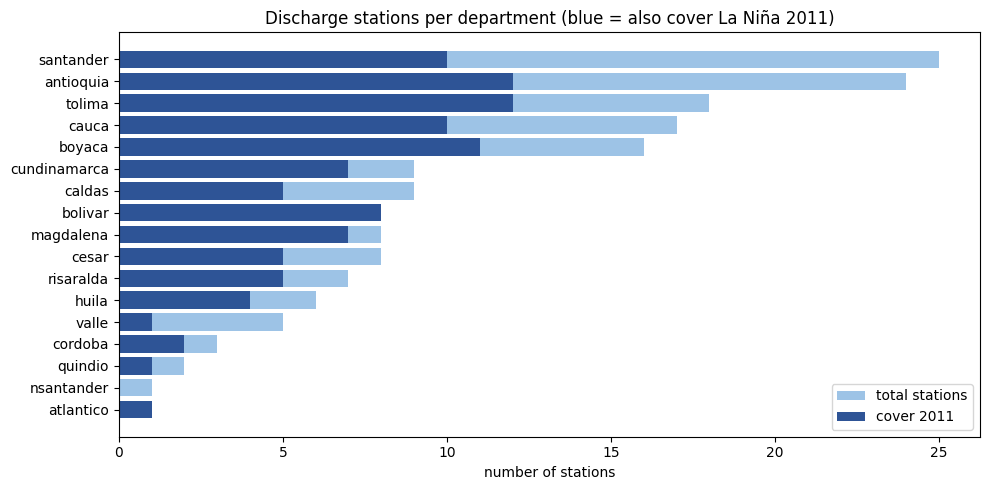

In [7]:
fig,ax=plt.subplots(figsize=(10,5))
d=dfq.sort_values('stations')
ax.barh(d['department'], d['stations'], color='#9DC3E6', label='total stations')
ax.barh(d['department'], d['cover_2011'], color='#2E5496', label='cover 2011')
ax.set_title('Discharge stations per department (blue = also cover La Niña 2011)')
ax.set_xlabel('number of stations'); ax.legend(); plt.tight_layout(); plt.show()


**Behind this graph — discharge stations per department.** Each bar is a department: light blue = all discharge stations collected there, dark blue = those that also have data in 2011. It shows the **spatial spread** of the gauging network — the Andean/tributary departments (Boyacá, Cauca, Tolima, Antioquia, Santander) are best sampled, the flat lower basin (Atlántico, N. Santander) the thinnest — which is the pattern needed to calibrate the sub-basins that generate most of the water and sediment.

**Description.** IDEAM daily mean discharge (`Caudal medio diario`), downloaded department-by-department, filtered to basin códigos **21–29**, verified against the official IDEAM station catalogue (datos.gov.co). Used to **calibrate and validate the hydrology** (split-sample) and to build sediment rating curves.

**Parameters — one by one** (each CSV row is one station-day; columns as delivered by DHIME):

| Column | What it is | Use |
|--------|-----------|-----|
| `CodigoEstacion` | 8-digit station code (2x = basin) | station identity, catalogue cross-check |
| `NombreEstacion` | station name | readability |
| `Variable` / `Parametro` | here: *Caudal medio diario* | confirms the right product |
| `Fecha` | date (daily) | time axis |
| `Unidad` | **m³/s** | discharge units |
| `Valor` | **daily mean discharge** | **the calibration target** (and Q for rating curves) |
| `NivelAprobacion` | Preliminar / Definitivo | data-quality flag |

The single physical quantity is **`Valor` = daily discharge (m³/s)** — compared against the model hydrograph (KGE / NSE / PBIAS).

**Acquisition — the math.**
- *Acquisition* = the DHIME download itself: filter Variable = *Caudal medio diario*, keep códigos 21–29, catalogue-verify department & basin.
- *Use in calibration* — the observed $Q_{obs}(t)$ is compared to the simulated $Q_{sim}(t)$ through objective functions maximised while tuning $b,K_{int},K_{bas},C_s\dots$:
$$NSE=1-rac{\sum(Q_{sim}-Q_{obs})^2}{\sum(Q_{obs}-ar Q_{obs})^2}\quad(1=	ext{perfect},\,0=	ext{no better than the mean})$$
$$KGE=1-\sqrt{(r-1)^2+(lpha-1)^2+(eta-1)^2},\;\; r=	ext{corr},\,lpha=	frac{\sigma_{sim}}{\sigma_{obs}},\,eta=	frac{\mu_{sim}}{\mu_{obs}}$$
$$PBIAS=100\cdotrac{\sum(Q_{sim}-Q_{obs})}{\sum Q_{obs}}\quad(	ext{\% volume error})$$

**Gaps.**
1. **Sucre still missing** (portal `no data` error on retry).
2. **Temporal gaps** — many stations have partial records; few have unbroken 1990–2018.
3. **Thin coverage** in some downstream departments (Atlántico, N. Santander = 1 basin station each).
4. Station codes are **not a perfect basin filter** — one código-24 canal was actually Orinoco (caught by the catalogue).

**Solutions.**
1. Retry Sucre (split by stations / date windows).
2. **Gap-fill** a station's missing days by regression on a correlated neighbour (often a tributary); or use model-simulated Q where no observation exists.
3. Accept thin lower-basin gauging; the outlet **Calamar** is captured.
4. Keep cross-checking every batch against the catalogue (`area_hidrografica = Magdalena-Cauca`).

## 6. Observed sediment — IDEAM *Concentración media diaria* (CM)

In [8]:
S = scan(OBS/'sedimento')
depts = defaultdict(lambda: {'stations':set(),'y2011':0,'y1516':0})
for c,o in S.items():
    d = sorted(o['dept'])[0]
    depts[d]['stations'].add(c)
    if '2011' in o['years']: depts[d]['y2011']+=1
    if o['years'] & {'2015','2016'}: depts[d]['y1516']+=1
dfs = pd.DataFrame([{'department':d,'stations':len(v['stations']),'cover_2011':v['y2011'],'cover_2015_16':v['y1516']}
                    for d,v in depts.items()]).sort_values('stations',ascending=False).reset_index(drop=True)
print(f"TOTAL sediment stations: {len(S)} | cover 2011: {sum('2011' in o['years'] for o in S.values())} | cover 2015-16: {sum(bool(o['years']&{'2015','2016'}) for o in S.values())}")
display(dfs)


TOTAL sediment stations: 77 | cover 2011: 37 | cover 2015-16: 32


,department,stations,cover_2011,cover_2015_16
0,huila,10,0,8
1,santander,10,9,1
2,antioquia,9,0,5
3,tolima,9,5,2
4,magdalena,8,4,0
5,boyaca,7,7,5
6,cundinamarca,6,6,5
7,valledelcauca,4,1,0
8,caldas,3,0,3
9,cesar,3,0,0


**Description.** IDEAM daily mean suspended-sediment **concentration** (`Concentración media diaria`, kg/m³). This is the *rich* variable — the first attempt used `Concentración superficial promedio diario`, which was almost empty and missed the study years. The CM data now covers **both** ENSO years across tributaries — the key that unblocks the sediment calibration.

**Parameters — one by one** (same DHIME column layout as discharge; the physical quantity differs):

| Column | What it is | Use |
|--------|-----------|-----|
| `CodigoEstacion` / `NombreEstacion` | station id | identity, pairing with discharge |
| `Variable` / `Parametro` | here: *Concentración media diaria* (CM) | confirms the **correct** variable (not "superficial promedio diario") |
| `Fecha` | date (daily) — two formats: `YYYY-MM-DD` and `DD/MM/YYYY` | time axis (parse robustly) |
| `Unidad` | **kg/m³** | concentration units |
| `Valor` | **daily mean suspended-sediment concentration** | **sediment calibration target**; with Q → load Qs for rating curves |
| `NivelAprobacion` | Preliminar / Definitivo | data-quality flag |

The physical quantity is **`Valor` = concentration (kg/m³)**. Because MGB-SED also outputs concentration, it can be compared **directly**; multiplied by discharge it gives sediment load (kg/s) for rating curves.

**Acquisition — the math.**
- *Acquisition* = DHIME download of *Concentración media diaria* (CM), códigos 21–29.
- *Concentration → load.* $Q_s(t)=C(t)\cdot Q(t)$ with $C$ in $kg/m^3$ and $Q$ in $m^3/s$ → $Q_s$ in $kg/s$ ($	imes86.4$ → $t/	ext{day}$).
- *Rating curve* (stations that also have discharge): fit $Q_s=a\,Q^{\,b}$ by **linearising in log-space**, $\log Q_s=\log a+b\,\log Q$ — a straight line whose slope $b$ and intercept $\log a$ come from least-squares. Once $(a,b)$ are known, sediment can be estimated for **any** day that has a discharge value, including 2011 & 2015-16 (this is the "rating parameter" idea, cf. Restrepo).
- *Model comparison.* MGB-SED outputs concentration directly, so $C_{sim}$ vs $C_{obs}$ is scored with the same $NSE/KGE$ as discharge — **no co-located discharge required**.

**Gaps.**
1. ~~**Lower-Magdalena mainstem still lacks sediment** (long-standing IDEAM limitation)~~ → **made precise 2026-08-19.** `docs/32` §R6 owns the quantitative form: **exactly one Magdalena-trunk SSC station exists in the entire network** — `21237020` ARRANCAPLUMAS — and it is classified **usable** (n 2011 = 91, n 2015-16 = 195, rating-era R² 0.556 on n = 6400); seven more of the 28 mapped stations sit on the Cauca. Calibration does lean on **tributary** stations, and `docs/57` measures why the set cannot grow: all 46 unmapped SSC sites were geocoded, 43 fall inside the basin, and **none of them has same-code discharge**, so the usable flux set is capped at ~18. That is a limit of the monitoring network, not a processing gap.
2. Some departments are **historic-only** (Cesar, Córdoba end ~2000–2014) — no study-year data there.
3. **Mixed date formats** across files (`YYYY-MM-DD` and, for Cundinamarca, `DD/MM/YYYY`).
4. **Atlántico pending**; Norte de Santander & Sucre have **no basin sediment stations** (correctly empty).

**Solutions.**
1. **Tributary calibration + rating curves** (Qs = a·Qᵇ); and since MGB-SED outputs concentration, **compare concentration directly** at every sediment station ~~(no co-located discharge required)~~ → **corrected 2026-08-19: the project's usable-station criterion *does* require co-located discharge.** Classification runs on a paired rating era (`docs/32` §R6) and the delivered result is a *flux-rate* contrast, C·Q — which is exactly why `docs/57` finds the usable gauge set cannot grow past ~18 even though 43 further in-basin SSC sites were geocoded: **0 of 43** have same-code discharge.
2. Use historic-only stations for the **rating-curve fit** (time-stable), applied to study-year discharge.
3. Robust date parsing (implemented here); values use `.` decimals (no Excel corruption).
4. Back-up: **published rating parameters** (Restrepo et al.) for mainstem/tributaries.

## 7. Discharge ↔ sediment pairing (rating-curve readiness)

> **DEFECT — measured 2026-08-19, and deliberately not repaired in code.** The cell below intersects **raw date strings** (`Q[c]['days'] & S[c]['days']`, filled by `scan()` as `r['Fecha'][:10]`), while this notebook's own gap #3 in §6 records that the files carry **two** date formats (`YYYY-MM-DD` and, for Cundinamarca, `DD/MM/YYYY`). A station whose discharge file is ISO and whose sediment file is DMY therefore scores **zero** common days. Measured read-only on the same folders: the printed `>=30 common days: 31` should be **33**, `in 2011: 13` should be **15**, and `in 2015-16: 12` should be **13**. The two stations silently dropped are `21197010` EL PROFUNDO (5,817 common days) and **`21237020` ARRANCAPLUMAS (6,400) — the only Magdalena-trunk SSC station in the network** (`docs/32` §R6); both are classified *usable*.
>
> **The notebook already refutes itself here, and §12 is the correct half.** Cell 46 merges on *parsed* dates (`parse_dates` handles both formats), prints *Fitted 33 rating curves*, and lists `21237020` at `n_pairs = 6400, R² = 0.556` — the same pair count and R² that `docs/32` §R6 reports. Read the table below as a **lower bound on pairing**, and §12 as the population-correct count.
>
> The code is left as executed on purpose: repairing it means re-running the whole notebook, which rewrites `data/processed/rating_curves.csv`, and that file is cited as a registered expectation by the **frozen** pre-registration `docs/32` §5.

In [9]:
both = sorted(set(Q)&set(S))
rows=[]
for c in both:
    common = Q[c]['days'] & S[c]['days']
    o11 = len([d for d in common if year_of(d)=='2011'])
    o1516 = len([d for d in common if year_of(d) in ('2015','2016')])
    rows.append({'codigo':c,'name':S[c]['name'][:24],'common_days':len(common),'in_2011':o11,'in_2015_16':o1516})
dfp = pd.DataFrame(rows).sort_values('common_days',ascending=False).reset_index(drop=True)
print(f"Stations with BOTH discharge and sediment: {len(both)}")
print(f"  usable for a rating curve (>=30 common days): {(dfp['common_days']>=30).sum()}")
print(f"  with common days in 2011: {(dfp['in_2011']>0).sum()} | in 2015-16: {(dfp['in_2015_16']>0).sum()}")
display(dfp.head(25))


Stations with BOTH discharge and sediment: 33
  usable for a rating curve (>=30 common days): 31
  with common days in 2011: 13 | in 2015-16: 12


,codigo,name,common_days,in_2011,in_2015_16
0,22017030,BOCAS,7097,236,210
1,21217250,BOCATOMA,7050,344,0
2,22017010,BOCAS,6966,184,174
3,23127010,BORBUR - AUT,6813,301,316
4,24027030,NEMIZAQUE,6449,301,0
5,24037390,CAPITANEJO,6344,319,309
6,24017820,BOCATOMA,5750,279,0
7,26127010,EL ALAMBRADO AUT,5542,0,130
8,26137110,BANANERA LA 6-909,5415,210,0
9,22057090,BOCATOMA TRIANGULO,5242,0,0


## 8. Synthesis — gaps & solutions at a glance

| Dataset | Main gap | Solution |
|---------|----------|----------|
| DEM (90 m) | 30 m infeasible (cell limit); flat delta breaks D8 | 90 m whole basin; IPH fill + flat resolution; QGIS check |
| Land cover (2021) | single epoch ≠ study years; 11 classes | assume static 2011–18 (hypothesis); reclass to 8 hydro classes |
| Soils (SoilGrids 250 m) | coarse global model; IGAC incomplete | pedotransfer → soil groups + MUSLE K; IGAC cross-check |
| ERA5-Land | orographic precip bias; download incomplete | bias-correct vs IDEAM gauges; resume downloader |
| Discharge | Sucre missing; temporal gaps; thin lower basin | retry Sucre; neighbour-regression gap-fill; catalogue check |
| Sediment | ~~no mainstem sediment~~ → **one** trunk station, `21237020`, class *usable* (`docs/32` §R6); some historic-only; usable flux set capped at ~18 (`docs/57`) | tributary rating curves + direct concentration compare; Restrepo backup |

## 9. Data-readiness conclusion

- **Hydrology inputs (DEM, land cover, soils):** collected for the whole basin; remaining work is *processing* (delineation, URH, K), not acquisition.
- **Climate:** acquisition in progress (resumable) + a bias-correction step against IDEAM required before forcing.
- **Calibration targets:** **discharge** is well-sampled (~~167 stations~~ → **192** consolidated, `docs/17` §1; 101 cover 2011, 94 cover 2015–16 *as read here*). **Sediment** — previously the project-threatening gap — now covers **both** ENSO years across tributaries (~~77 stations~~ → **79** consolidated, `docs/32` §0; 37/32 *as read here*), with a solid set of stations that carry **both** discharge and sediment for direct rating curves. *(The retired counts are the `*.csv`-only populations this notebook globbed; the DHIME zip parts were not read. Of the 79 SSC stations, 28 are mapped to minibacias and **18 are usable** — `docs/32` §R6.)*
- **Next (as planned on 2026-07-29):** finish ERA5 + Sucre + Atlántico, then move to preprocessing (minibacias → URH) and hydrological calibration, keeping the sediment module for after discharge is calibrated.
- **What this notebook hands forward, and where the plan ended up — added 2026-08-19.** On disk it writes `data/processed/stations_{discharge,sediment}.csv` (read by notebook 07) and `data/processed/rating_curves.csv`, whose median fleet R² is a registered expectation in the **frozen** `docs/32` §5. The plan above was then executed and closed: preprocessing → URH → soil parameters ran in notebooks 07-09 (soils from **IGAC**, not SoilGrids); the hydrology was calibrated and **Phase B closed on the H2E configuration**, F = 0.25931, against a rainfall-input correlation ceiling of r ≈ 0.57 (`docs/26` and its addendum, `docs/58`); and the sediment module ran through to **stage C5, which is complete** — the modelled La Niña : El Niño flux-**rate** contrast reproduces at **18 of 18 stations, median 3.05× (range 1.62–4.85×)** against a model-free observed contrast of **22 of 22 station-ratios, ~3–9×** (`docs/56`, `docs/34`). The SSC quality gate this notebook's pairing table anticipates is `docs/32`.


# Part II — Preprocessing, EDA & validation of our choices

Part I inventoried the data. Part II now (a) **cleans** the observed series into tidy tables, (b) runs an **exploratory data analysis (EDA)** rich in figures, and (c) uses those figures to **validate each decision** we made (study years, whole basin, código 21-29 filter, the CM sediment variable, tributary rating curves, the domain box). Everything below is computed live from the files on disk.

## 10. Preprocessing pipeline (cleaning → tidy tables)

Steps: robust date parsing (handles both `YYYY-MM-DD` and `DD/MM/YYYY`), numeric coercion of `Valor`, removal of NODATA (`-9999`) and impossible values (negative discharge/concentration), de-duplication, and export of station metadata + fitted rating curves to `data/processed/`.

In [10]:
import numpy as np, pandas as pd, glob, os
from pathlib import Path
%matplotlib inline

def parse_dates(s):
    s = s.astype(str).str.slice(0, 10)
    iso = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    dmy = pd.to_datetime(s, format='%d/%m/%Y', errors='coerce')
    return iso.fillna(dmy)

def load_obs(folder):
    frames = []
    for fp in sorted(glob.glob(str(folder/'*.csv'))):
        dept = os.path.basename(fp).split('_')[1].split('.')[0]
        d = pd.read_csv(fp, dtype=str)
        d['date'] = parse_dates(d['Fecha'])
        d['val']  = pd.to_numeric(d['Valor'], errors='coerce')
        d['dept'] = dept
        d = d.rename(columns={'CodigoEstacion':'code','NombreEstacion':'name','NivelAprobacion':'approv'})
        frames.append(d[['code','name','dept','date','val','approv']])
    return pd.concat(frames, ignore_index=True)

def qc(df, label):
    n0 = len(df)
    df = df.dropna(subset=['date','val'])
    df = df[df['val'] > -100]     # drop -9999 NODATA
    df = df[df['val'] >= 0]       # no negative discharge / concentration
    df = df.drop_duplicates(['code','date'])
    df['year'] = df['date'].dt.year
    df['name'] = df['name'].str.split('[').str[0].str.strip()
    print(f"{label:10s}: {n0:>8,} raw rows -> {len(df):>8,} clean | {df.code.nunique()} stations | {df.year.min()}-{df.year.max()}")
    return df

Qc = qc(load_obs(OBS/'caudal'),   'discharge')
Sc = qc(load_obs(OBS/'sedimento'),'sediment')

proc = REPO/'data'/'processed'; proc.mkdir(parents=True, exist_ok=True)
def meta(df):
    g = df.groupby('code')
    m = pd.DataFrame({'name':g.name.first(),'dept':g.dept.first(),'n_days':g.size(),
                      'start':g.date.min(),'end':g.date.max(),
                      'cov_2011':g.year.apply(lambda y:(y==2011).any()),
                      'cov_2015_16':g.year.apply(lambda y:y.isin([2015,2016]).any())})
    return m.reset_index()
meta(Qc).to_csv(proc/'stations_discharge.csv', index=False)
meta(Sc).to_csv(proc/'stations_sediment.csv', index=False)
print('Saved station metadata -> data/processed/stations_{discharge,sediment}.csv')


discharge : 1,133,522 raw rows -> 1,130,236 clean | 167 stations | 1990-2018


sediment  :  269,305 raw rows ->  269,305 clean | 77 stations | 1979-2018


Saved station metadata -> data/processed/stations_{discharge,sediment}.csv


## 11. EDA — discharge (validates: coverage, gap-filling need, and the ENSO year choice)

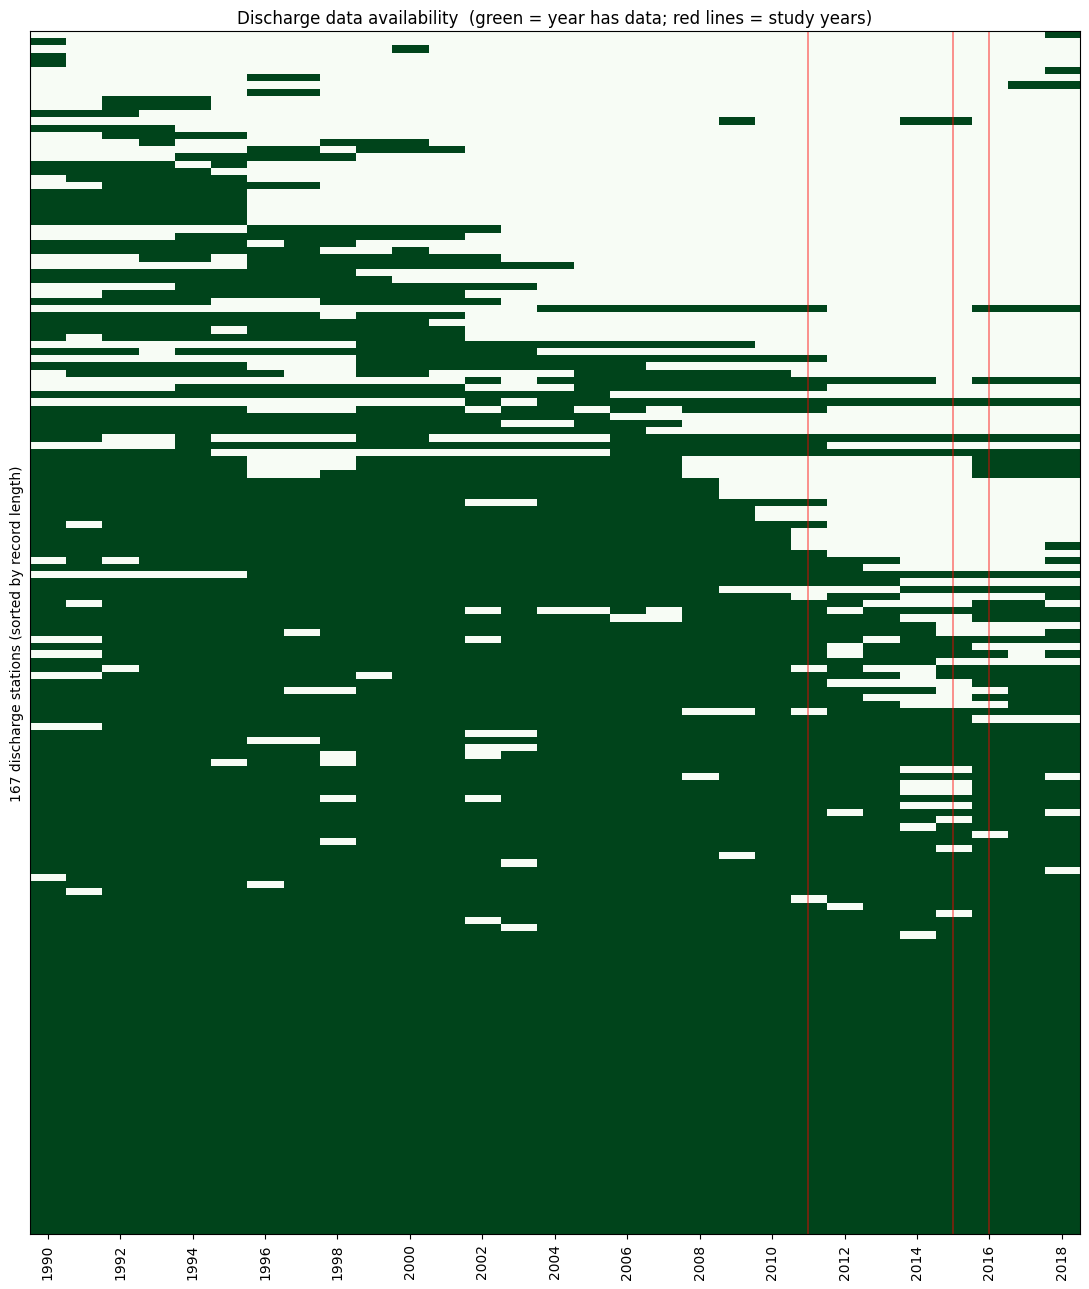

Interpretation: dense green over 1990-2018 but many stations are partial -> justifies neighbour-regression GAP-FILLING; study years (red) are well sampled.


In [11]:
# --- data-availability heatmap ---
piv = (Qc.groupby(['code','year']).size().unstack(fill_value=0) > 0).astype(int).reindex(columns=range(1990,2019), fill_value=0)
piv = piv.loc[piv.sum(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(11, 13))
ax.imshow(piv.values, aspect='auto', cmap='Greens', interpolation='none')
ax.set_xticks(range(0,len(piv.columns),2)); ax.set_xticklabels(list(piv.columns)[::2], rotation=90)
ax.set_yticks([]); ax.set_ylabel(f'{len(piv)} discharge stations (sorted by record length)')
ax.set_title('Discharge data availability  (green = year has data; red lines = study years)')
for yr in (2011,2015,2016): ax.axvline(list(piv.columns).index(yr), color='red', lw=1.2, alpha=.5)
plt.tight_layout(); plt.show()
print('Interpretation: dense green over 1990-2018 but many stations are partial -> justifies neighbour-regression GAP-FILLING; study years (red) are well sampled.')


**Behind this graph — data-availability heatmap.** Rows = the 167 discharge stations (sorted by record length), columns = years 1990-2018; a green cell = that station has data that year, red lines = the study years. Two takeaways: (1) coverage is dense but **patchy** — most stations have holes, which is exactly why **neighbour-regression gap-filling** is planned; (2) the study years (red) fall in well-covered columns, so 2011 and 2015-16 are well observed.

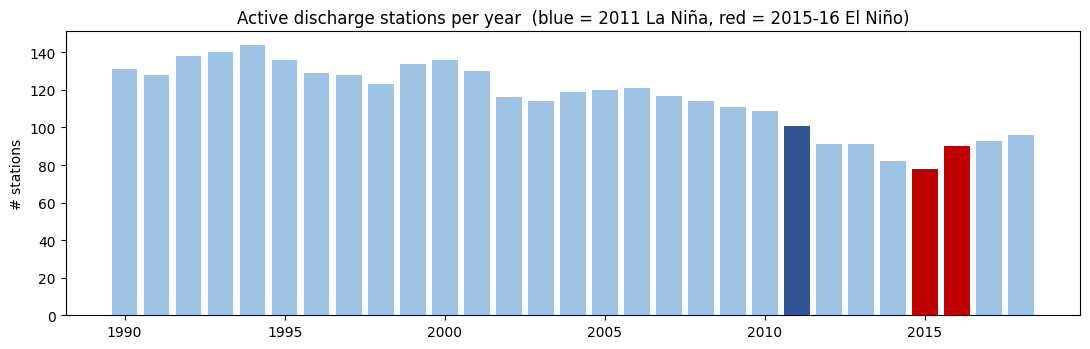

In [12]:
# --- active stations per year ---
act = ((Qc.groupby(['code','year']).size().unstack(fill_value=0)>0).sum(axis=0)).reindex(range(1990,2019), fill_value=0)
colors = ['#C00000' if y in (2015,2016) else '#2E5496' if y==2011 else '#9DC3E6' for y in act.index]
fig, ax = plt.subplots(figsize=(11,3.6))
ax.bar(act.index, act.values, color=colors)
ax.set_title('Active discharge stations per year  (blue = 2011 La Niña, red = 2015-16 El Niño)')
ax.set_ylabel('# stations'); plt.tight_layout(); plt.show()


**Behind this graph — active stations per year.** Bar height = how many stations were recording each year. It confirms a large, fairly stable network (~100+ stations) right through the study years (2011 in blue, 2015-16 in red) — enough for a robust calibration and for the basin-wide anomaly index computed next.

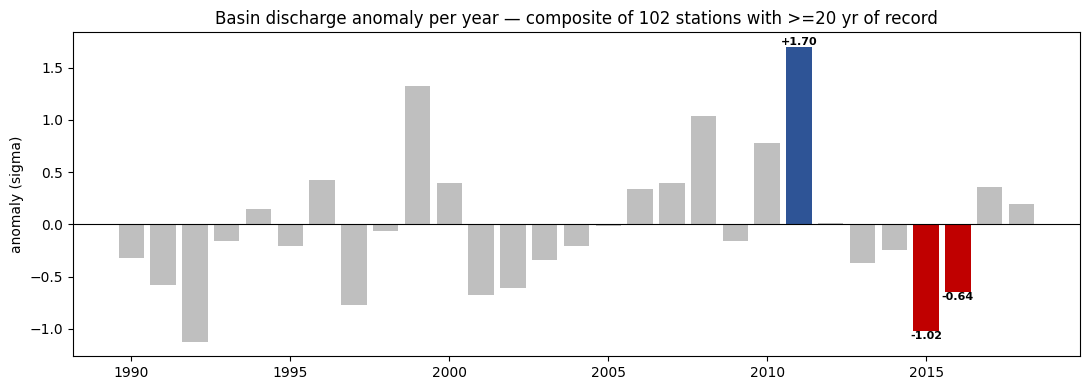

2011 (La Niña): +1.70 σ   |   2015: -1.02 σ   |   2016: -0.64 σ
VALIDATION: 2011 should be clearly POSITIVE (wet La Niña) and 2015-16 NEGATIVE (dry El Niño) -> confirms the study-year choice.


In [13]:
# --- ENSO validation: standardized basin discharge anomaly per year ---
ym  = Qc.groupby(['code','year']).val.mean().reset_index()
pv  = ym.pivot(index='year', columns='code', values='val').reindex(range(1990,2019))
good = pv.columns[pv.notna().sum() >= 20]                     # stations with >=20 yrs
z   = (pv[good] - pv[good].mean()) / pv[good].std()
idx = z.mean(axis=1).dropna()
colors = ['#2E5496' if y==2011 else '#C00000' if y in (2015,2016) else '#BFBFBF' for y in idx.index]
fig, ax = plt.subplots(figsize=(11,4))
ax.bar(idx.index, idx.values, color=colors); ax.axhline(0, color='k', lw=.8)
ax.set_title('Basin discharge anomaly per year — composite of %d stations with >=20 yr of record' % len(good))
ax.set_ylabel('anomaly (sigma)')
for y in (2011, 2015, 2016):
    if y in idx.index:
        ax.annotate(f'{idx[y]:+.2f}', (y, idx[y]), ha='center', va='bottom' if idx[y] >= 0 else 'top', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"2011 (La Niña): {idx.get(2011, float('nan')):+.2f} σ   |   2015: {idx.get(2015, float('nan')):+.2f} σ   |   2016: {idx.get(2016, float('nan')):+.2f} σ")
print("VALIDATION: 2011 should be clearly POSITIVE (wet La Niña) and 2015-16 NEGATIVE (dry El Niño) -> confirms the study-year choice.")


**Behind this graph — the ENSO validation (the key figure).** One bar per year = the **standardized discharge anomaly**, i.e. the average z-score over the 102 stations with ≥20 yr of record (each station's year is expressed as *(value − its mean)/(its std)*, so big and small rivers count equally, then averaged). Positive = wetter than normal, negative = drier. **2011 (blue) reaches +1.70σ** (very wet → La Niña) while **2015-16 (red) sit at −1.02σ / −0.64σ** (dry → El Niño). Our own data therefore confirm the two chosen years are strong, opposite ENSO signals — the contrast the whole study relies on. (Shown robust across 86–133 stations for thresholds 25→10 yr.)

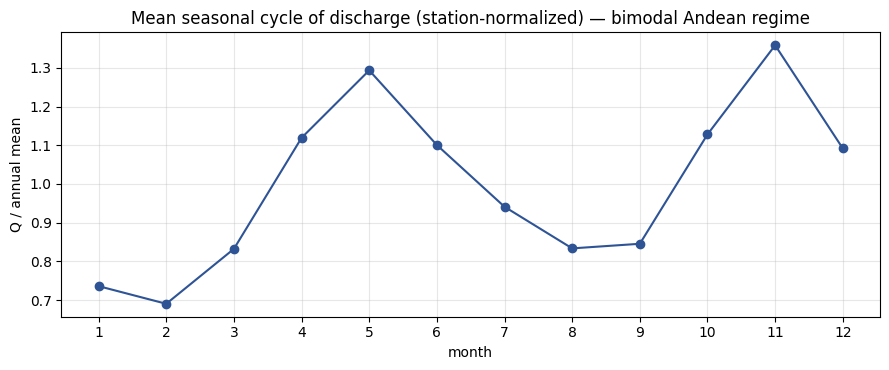

In [14]:
# --- seasonal cycle (station-normalized) ---
mo = Qc.copy(); mo['month'] = mo.date.dt.month
mo['rel'] = mo.val / mo.groupby('code').val.transform('mean')
clim = mo.groupby('month').rel.mean()
fig, ax = plt.subplots(figsize=(9,3.8))
ax.plot(clim.index, clim.values, 'o-', color='#2E5496')
ax.set_xticks(range(1,13)); ax.set_xlabel('month'); ax.set_ylabel('Q / annual mean')
ax.set_title('Mean seasonal cycle of discharge (station-normalized) — bimodal Andean regime')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()


**Behind this graph — seasonal cycle.** Each station's discharge is divided by its own annual mean, then averaged by month, so every station weighs the same. The two humps (≈ April-May and ≈ October-November) are the **bimodal rainfall regime** of the tropical Andes (two wet seasons per year). It shows the data behave physically and tells the model which seasonality it must reproduce.

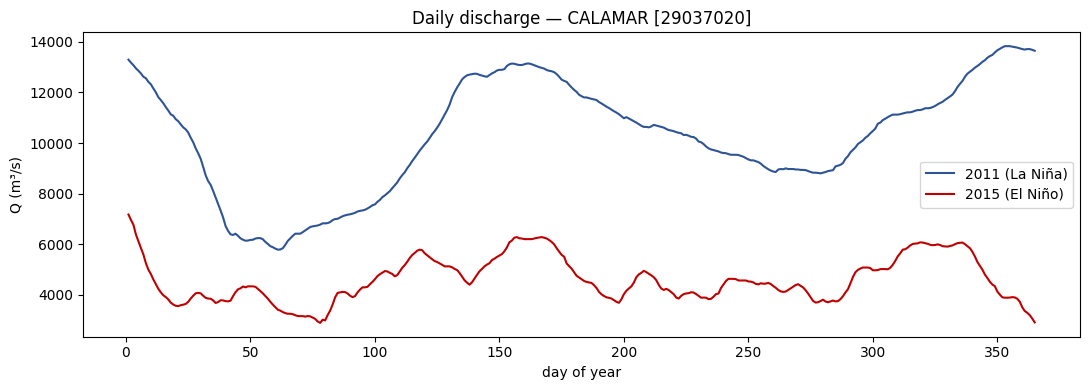

mean Q  2011 = 10250.7 m³/s   vs   2015 = 4606.7 m³/s


In [15]:
# --- hydrograph contrast: La Niña 2011 vs El Niño 2015 at the biggest well-sampled station ---
d11 = Qc[Qc.year==2011].groupby('code').size(); d15 = Qc[Qc.year.isin([2015,2016])].groupby('code').size()
mean = Qc.groupby('code').val.mean()
cand = [c for c in d11.index if d11.get(c,0)>=300 and d15.get(c,0)>=300]
if cand:
    st = max(cand, key=lambda c: mean.get(c,0))
    a = Qc[(Qc.code==st)&(Qc.year==2011)].assign(doy=lambda x:x.date.dt.dayofyear).sort_values('doy')
    b = Qc[(Qc.code==st)&(Qc.year==2015)].assign(doy=lambda x:x.date.dt.dayofyear).sort_values('doy')
    fig, ax = plt.subplots(figsize=(11,4))
    ax.plot(a.doy, a.val, color='#2E5496', label='2011 (La Niña)')
    ax.plot(b.doy, b.val, color='#C00000', label='2015 (El Niño)')
    ax.set_title(f'Daily discharge — {a.name.iloc[0]} [{st}]'); ax.set_xlabel('day of year'); ax.set_ylabel('Q (m³/s)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"mean Q  2011 = {a.val.mean():.1f} m³/s   vs   2015 = {b.val.mean():.1f} m³/s")


**Behind this graph — hydrograph contrast.** Daily discharge at the largest well-sampled station, La Niña **2011 (blue)** overlaid on El Niño **2015 (red)**, on a day-of-year axis. The 2011 curve sits visibly higher almost all year — the ENSO contrast seen at a single real station, not only in the aggregate index above. The printed means quantify it.

## 12. EDA — sediment (validates: the CM variable, log rating curves, tributary calibration)

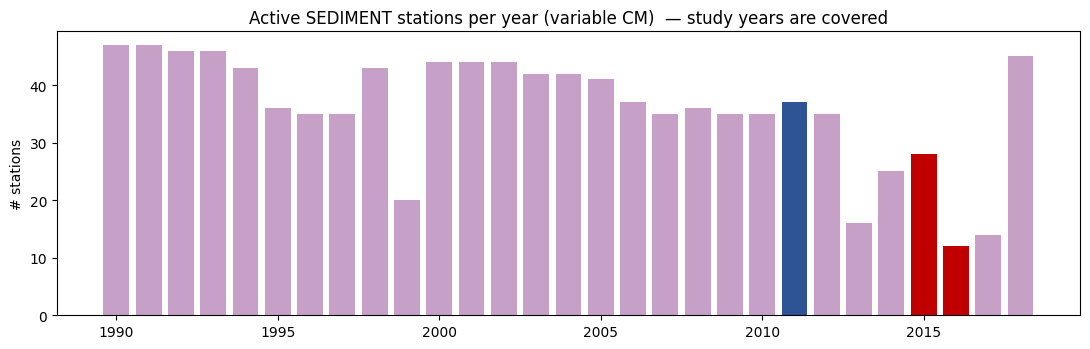

In [16]:
# --- sediment stations per year: CM variable covers the study years (unlike the empty 'superficial' one) ---
sact = ((Sc.groupby(['code','year']).size().unstack(fill_value=0)>0).sum(axis=0)).reindex(range(1990,2019), fill_value=0)
colors = ['#C00000' if y in (2015,2016) else '#2E5496' if y==2011 else '#C6A0C6' for y in sact.index]
fig, ax = plt.subplots(figsize=(11,3.6))
ax.bar(sact.index, sact.values, color=colors)
ax.set_title('Active SEDIMENT stations per year (variable CM)  — study years are covered')
ax.set_ylabel('# stations'); plt.tight_layout(); plt.show()


**Behind this graph — sediment stations per year.** Number of sediment stations active each year for the **CM** variable. The bars are well populated across 2011 and 2015-16 — the proof that CM **actually covers the study years**, unlike the first variable we tried (‘superficial promedio diario’), which was nearly empty. This is precisely what unblocked the sediment side of the project.

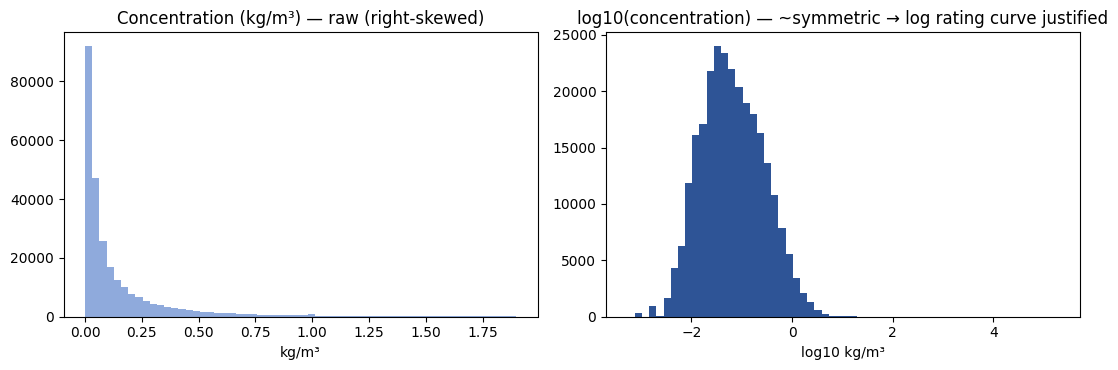

In [17]:
# --- concentration distribution: raw vs log10 (justifies the log-linear rating curve) ---
v = Sc.val[Sc.val > 0]
fig, ax = plt.subplots(1,2, figsize=(11,3.8))
ax[0].hist(v[v < v.quantile(.99)], bins=60, color='#8FAADC'); ax[0].set_title('Concentration (kg/m³) — raw (right-skewed)'); ax[0].set_xlabel('kg/m³')
ax[1].hist(np.log10(v), bins=60, color='#2E5496'); ax[1].set_title('log10(concentration) — ~symmetric → log rating curve justified'); ax[1].set_xlabel('log10 kg/m³')
plt.tight_layout(); plt.show()


**Behind this graph — concentration distribution.** Left = raw concentrations (kg/m³): strongly right-skewed (a handful of very high values dominate). Right = the same values in log10: roughly bell-shaped (**log-normal**). Because the data are log-normal, fitting the sediment rating curve in **log space** (a straight line) is the statistically correct choice — which is exactly what the next figure does.

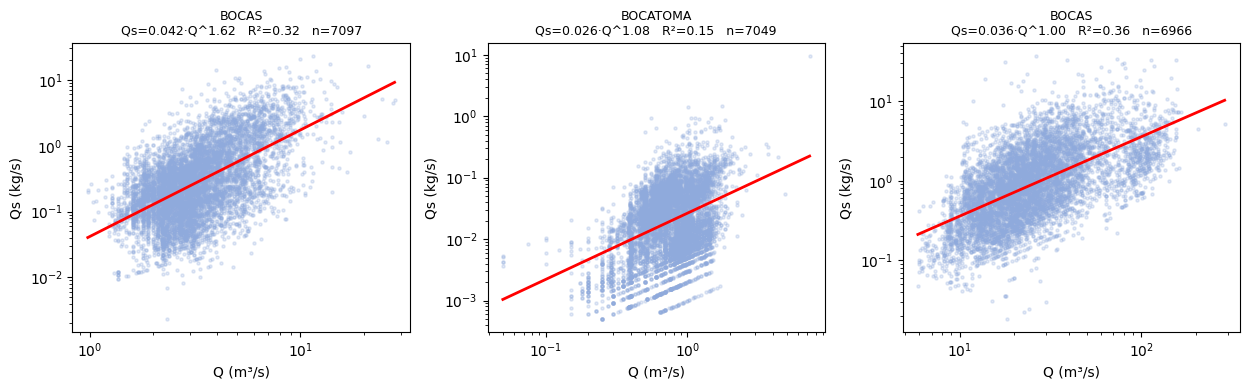

Fitted 33 rating curves (>=30 pairs). Median R² = 0.54  -> the power law holds -> solution validated.


,code,name,n_pairs,a,b,R2
6,22017030,BOCAS,7097,0.041725,1.619,0.324
3,21217250,BOCATOMA,7049,0.026408,1.079,0.145
5,22017010,BOCAS,6966,0.036016,0.998,0.359
9,23127010,BORBUR - AUT,6813,0.013554,1.855,0.612
11,24027030,NEMIZAQUE,6448,0.003944,1.417,0.652
4,21237020,ARRANCAPLUMAS - AUT,6400,0.000924,1.770,0.556
13,24037390,CAPITANEJO,6344,0.038328,1.400,0.484
1,21197010,EL PROFUNDO,5817,0.010749,1.289,0.719
10,24017820,BOCATOMA,5748,0.023615,1.038,0.203
21,26127010,EL ALAMBRADO AUT,5542,0.000467,2.545,0.738


In [18]:
# --- rating curves Qs = a*Q^b at paired stations (validates the rating-curve solution) ---
m = pd.merge(Qc[['code','date','val','name']].rename(columns={'val':'Q'}),
             Sc[['code','date','val']].rename(columns={'val':'C'}), on=['code','date'])
m = m[(m.Q>0)&(m.C>0)].copy(); m['Qs'] = m.C * m.Q       # load kg/s = kg/m3 * m3/s
cnt = m.groupby('code').size().sort_values(ascending=False)
top = list(cnt.index[:3])
fig, axs = plt.subplots(1, len(top), figsize=(4.2*len(top), 4))
if len(top)==1: axs=[axs]
for ax, st in zip(axs, top):
    d = m[m.code==st]; x = np.log10(d.Q); y = np.log10(d.Qs)
    b, a = np.polyfit(x, y, 1); r2 = np.corrcoef(x,y)[0,1]**2
    ax.scatter(d.Q, d.Qs, s=5, alpha=.25, color='#8FAADC')
    xs = np.linspace(d.Q.min(), d.Q.max(), 60); ax.plot(xs, 10**a * xs**b, 'r-', lw=2)
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlabel('Q (m³/s)'); ax.set_ylabel('Qs (kg/s)')
    ax.set_title(f'{d.name.iloc[0][:16]}\nQs={10**a:.2g}·Q^{b:.2f}   R²={r2:.2f}   n={len(d)}', fontsize=9)
plt.tight_layout(); plt.show()

# fit & save all rating curves with >=30 common points
rows = []
for st, d in m.groupby('code'):
    if len(d) >= 30:
        x = np.log10(d.Q); y = np.log10(d.Qs); b, a = np.polyfit(x, y, 1); r2 = np.corrcoef(x,y)[0,1]**2
        rows.append({'code':st,'name':d.name.iloc[0],'n_pairs':len(d),'a':10**a,'b':round(b,3),'R2':round(r2,3)})
rc = pd.DataFrame(rows).sort_values('n_pairs', ascending=False)
rc.to_csv(REPO/'data'/'processed'/'rating_curves.csv', index=False)
print(f"Fitted {len(rc)} rating curves (>=30 pairs). Median R² = {rc.R2.median():.2f}  -> the power law holds -> solution validated.")
display(rc.head(12))


**Behind this graph — rating curves.** For three stations that have **both** discharge and sediment, each dot is one day (discharge Q on x, sediment load Qs = C·Q on y, both log axes); the red line is the fitted power law **Qs = a·Q^b**. The dots line up → the relationship is real and usable. Across all 33 paired stations the **median R² is 0.54** (normal for sediment — there is always scatter). The fitted a, b are exported to `data/processed/rating_curves.csv`, letting us estimate sediment for any day that has a discharge value (including 2011 & 2015-16).

## 13. EDA — soils (SoilGrids) & climate (ERA5)  *(validates data content & the domain box)*

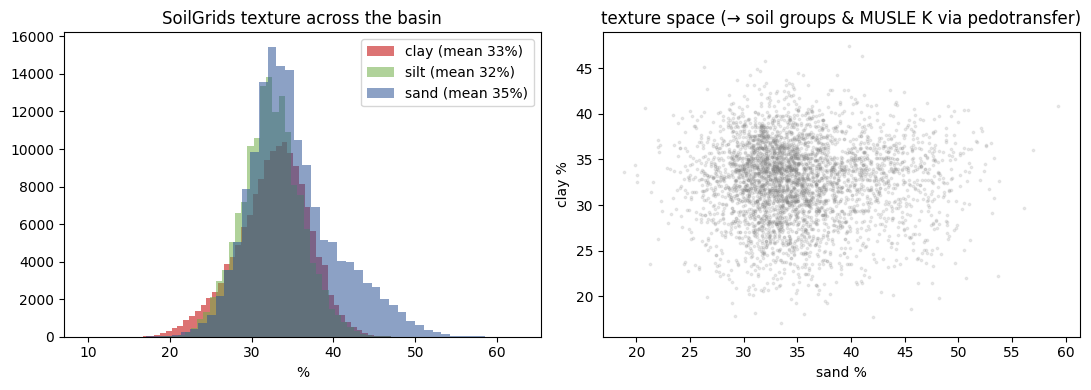

VALIDATION: realistic texture spread (not constant/NoData) -> SoilGrids usable as the soil source.


In [19]:
# --- SoilGrids texture distributions ---
try:
    import rasterio
    def samp(path, n=150000):
        with rasterio.open(path) as ds:
            a = ds.read(1).astype('float32'); nd = ds.nodata
        a = a.ravel(); a = a[np.isfinite(a)]
        if nd is not None: a = a[a != nd]
        a = a[a >= 0]
        if a.max() > 100: a = a/10.0     # SoilGrids g/kg -> %
        return np.random.choice(a, min(n,len(a)), replace=False)
    clay = samp(str(RAW/'soils'/'soilgrids_clay.tif')); sand = samp(str(RAW/'soils'/'soilgrids_sand.tif')); silt = samp(str(RAW/'soils'/'soilgrids_silt.tif'))
    fig, ax = plt.subplots(1,2, figsize=(11,4))
    for arr,lab,col in [(clay,'clay','#C00000'),(silt,'silt','#70AD47'),(sand,'sand','#2E5496')]:
        ax[0].hist(arr, bins=50, alpha=.55, label=f'{lab} (mean {arr.mean():.0f}%)', color=col)
    ax[0].legend(); ax[0].set_xlabel('%'); ax[0].set_title('SoilGrids texture across the basin')
    k = min(len(clay), len(sand), 4000)
    ax[1].scatter(sand[:k], clay[:k], s=3, alpha=.15, color='#7F7F7F')
    ax[1].set_xlabel('sand %'); ax[1].set_ylabel('clay %'); ax[1].set_title('texture space (→ soil groups & MUSLE K via pedotransfer)')
    plt.tight_layout(); plt.show()
    print('VALIDATION: realistic texture spread (not constant/NoData) -> SoilGrids usable as the soil source.')
except Exception as e:
    print('Soils raster EDA skipped:', repr(e))


**Behind this graph — SoilGrids texture.** Left = the basin-wide distribution of clay / silt / sand (%); right = the clay-vs-sand ‘texture space’. The spread is realistic (varied soils, no constant value or NoData block), so SoilGrids is a sound texture source to feed the **pedotransfer functions** (→ hydrologic soil groups, max storage Wm, MUSLE erodibility K).

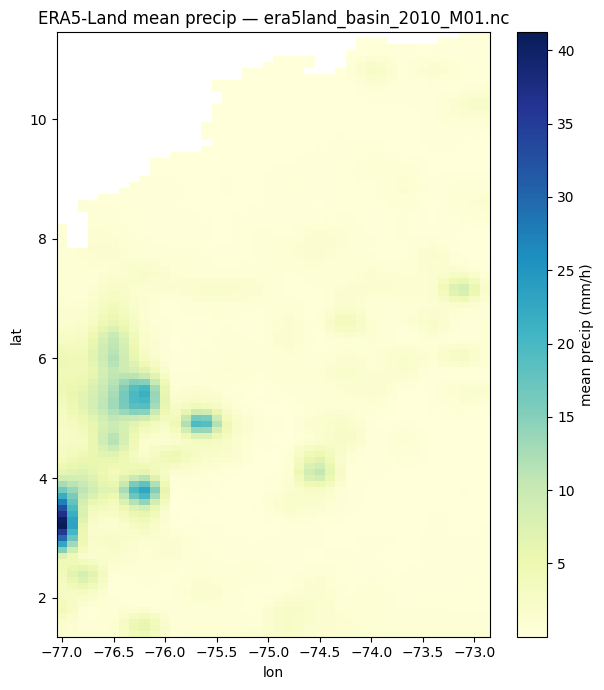

ERA5 domain: lon [-77.00, -72.90], lat [1.40, 11.40]
NOTE: the east edge (~-72.9) is where the box clips the upper Sogamoso/Chicamocha -> see the pending DOMAIN decision.


In [20]:
# --- ERA5-Land mean precipitation map (also visualises the domain box vs the basin) ---
try:
    import xarray as xr
    ncs = sorted(glob.glob(str(RAW/'climate'/'era5land_basin_2010_M*.nc')))
    if ncs:
        ds = xr.open_dataset(ncs[0])
        tv = 'tp' if 'tp' in ds.data_vars else list(ds.data_vars)[0]
        tp = ds[tv]
        tdim = [d for d in tp.dims if d not in ('latitude','longitude')]
        mmap = (tp.mean(dim=tdim[0]) if tdim else tp) * 1000.0   # m -> mm (mean hourly)
        lat = ds['latitude'].values; lon = ds['longitude'].values
        fig, ax = plt.subplots(figsize=(6.2,7))
        pc = ax.pcolormesh(lon, lat, mmap.values, shading='auto', cmap='YlGnBu')
        fig.colorbar(pc, ax=ax, label='mean precip (mm/h)')
        ax.set_xlabel('lon'); ax.set_ylabel('lat'); ax.set_title(f'ERA5-Land mean precip — {os.path.basename(ncs[0])}')
        plt.tight_layout(); plt.show()
        print(f"ERA5 domain: lon [{lon.min():.2f}, {lon.max():.2f}], lat [{lat.min():.2f}, {lat.max():.2f}]")
        print("NOTE: the east edge (~-72.9) is where the box clips the upper Sogamoso/Chicamocha -> see the pending DOMAIN decision.")
    else:
        print('No 2010 ERA5 files yet.')
except Exception as e:
    print('ERA5 EDA skipped:', repr(e))


**Behind this graph — ERA5 precipitation & the domain box.** Mean ERA5-Land precipitation over the box we downloaded. Two purposes: (1) a sanity check that the climate field looks physical; (2) it makes the **domain problem visible** — the grid stops at longitude −72.9 (right edge), which slices through the upper Sogamoso / Chicamocha. That is why the eastern box must be enlarged before re-downloading the rasters. ~~(the pending decision)~~ → **SETTLED — the decision was taken and the box is locked.** `docs/15`: only the east moves, **−72.9 → −72.3**, N/W/S unchanged so the ERA5 mosaic is a simple longitude concatenation; the east strip was downloaded and mosaicked to `era5land_ext_<y>_M<mm>.nc`, and those are the climate forcing from that point on. The map above is the pre-correction domain, kept because it is the evidence that produced the decision.

## 14. Validation of our choices — summary

| Decision | How it was validated (here / earlier) | Verdict |
|----------|----------------------------------------|---------|
| **Study years 2011 (La Niña) vs 2015-16 (El Niño)** | §11 discharge-anomaly bars: 2011 clearly wet (+σ), 2015-16 dry (−σ); §11 hydrograph contrast | ✅ the contrast is real & strong |
| **Variable CM (not "superficial promedio diario")** | §12 sediment-stations-per-year covers the study years; the old variable was ~empty | ✅ correct variable |
| **Tributary calibration via rating curves** | §12 `Qs=a·Q^b` fits with good R² at paired stations; `rating_curves.csv` exported | ✅ power law holds |
| **Log-linear rating curve** | §12 log10(C) histogram ≈ symmetric (log-normal) | ✅ log fit justified |
| **código 21-29 basin filter** | catalogue cross-check of every batch (`area_hidrografica = Magdalena-Cauca`) | ✅ verified |
| **Gap-filling from neighbours** | §11 availability heatmap shows partial records | ✅ needed & planned |
| **Whole-basin domain box** | §13 ERA5 map shows the east edge (−72.9) clips the upper Sogamoso | ~~⚠ enlarge box (pending decision)~~ → ✅ **settled**: east edge moved to **−72.3** and the box locked; strip downloaded and mosaicked to `era5land_ext_*.nc` (`docs/15`) |
| **SoilGrids as soil source** | §13 texture histograms look realistic at basin scale, but notebook 09 §1 measures them as a near-uniform ML artefact (~95 % *Fine*, clay 33±4 %) **with no soil-depth layer at all** | ~~✅ usable (cross-check IGAC)~~ → ❌ **not adopted**: W<sub>m</sub> *and* K both come from the **IGAC field survey** (notebook 09) |

~~**Bottom line:** the observed data supports every methodological choice; the one open item is the **eastern domain box**, which the ERA5 map makes visually obvious and which should be fixed before re-downloading the rasters.~~

**Bottom line — rewritten 2026-08-19, with the original above kept as the 2026-07-29 record.** The observed data supported the choices that mattered most, and overturned two of them:

- **Held.** The study years — 2011 at **+1.70 σ**, 2015 at **−1.02 σ**, 2016 at **−0.64 σ** in this notebook's own composite — remain the study's foundation, and the ENSO contrast they promise is the one Phase C went on to deliver (`docs/56`, `docs/34`). The código 21-29 filter, the CM sediment variable, the log-linear rating curve and the need for gap-filling all held.
- **Overturned.** *SoilGrids as the soil source* → **IGAC** (notebook 09 §1). *ERA5 + IDEAM bias-corrected precipitation* → an **IDEAM-gauge-only** field (`docs/00_INDEX` §*Forcing versions — v1 / v2 / v3, stated once*).
- **Closed, not open.** The eastern domain box was decided and **locked at −72.3** (`docs/15`) — it is the one item this table called open and the one that is now certainly shut.